In [9]:
import sys
sys.path.append("../src/meta-estimators")

In [2]:
import pandas as pd
import mygene

mg = mygene.MyGeneInfo()

def ensg_to_symbol(ensg_ids):
    # Remove version suffixes like ENSG00000141510.18
    clean_ids = pd.Series(ensg_ids).astype(str).str.replace(r"\.\d+$", "", regex=True)

    res = mg.querymany(
        clean_ids.tolist(),
        scopes="ensembl.gene",
        fields="symbol",
        species="human",
        as_dataframe=True,
    )

    mapping = res["symbol"].to_dict()
    return clean_ids.map(mapping).values

In [53]:
df = pd.read_csv("https://raw.githubusercontent.com/Asthayadav09/airway-RNA-Seq-Dataset/main/airway_DESeq2_results.csv", index_col=0)
df["symbol"] = ensg_to_symbol(df.index)

1 input query terms found dup hits:	[('ENSG00000175711', 2)]
654 input query terms found no hit:	['ENSG00000005955', 'ENSG00000006114', 'ENSG00000017621', 'ENSG00000034063', 'ENSG00000056661', 'ENS


In [ ]:
import pandas as pd
# df = pd.read_csv("DE_Results.csv").set_index("symbol")

In [54]:
df = df.dropna().set_index("symbol")
df = df.reset_index().drop_duplicates(subset=["symbol"]).set_index("symbol")

In [55]:
from enrichr import GeneOntologyLibraries
go_terms = GeneOntologyLibraries().pull_assignment_matrix("GO_Biological_Process_2025")

In [56]:
from ipf import ReweightingPreparer, IterativeProportionalFitting

deseq_results, go_terms, row_marginals, column_marginals = ReweightingPreparer.clean(go_terms, df)
balanced_matrix = IterativeProportionalFitting().get_balanced_matrix(
    go_terms, 
    row_marginals, 
    column_marginals,
    tolerance=1e-4
)

IPF Running:   1%|▏         | 13/1000 [00:06<08:08,  2.02it/s, % Change (Frob Norm)=9.17e-5] 


<Axes: xlabel='metaLFC', ylabel='log10padj'>

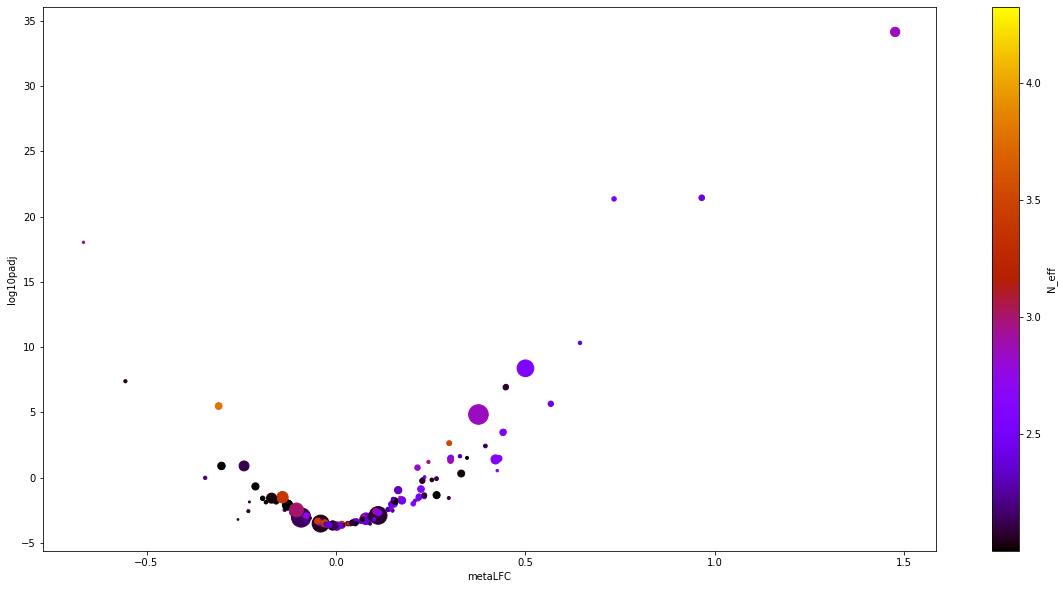

In [57]:
from meta import GeneOntologyDifferentialResults

gene_ontology_results = GeneOntologyDifferentialResults.meta_estimates(deseq_results, balanced_matrix)
gene_ontology_results.query("top1_contribution < 0.9 and N_eff > 2") \
    .plot.scatter(x="metaLFC", y="log10padj", c="N_eff", s="weight", figsize=(20, 10), cmap="gnuplot")

<Axes: xlabel='ratio', ylabel='metaLFC'>

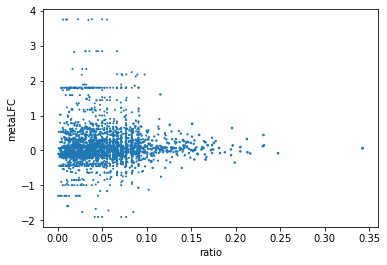

In [58]:
gene_ontology_results.eval("ratio = N_eff / n_terms").query("n_terms > 10").plot.scatter(x="ratio", y="metaLFC", s="N_eff")

In [59]:
gene_ontology_results.query("padj < 0.05 and N_eff > 2").sort_values(by="metaLFC")

,n_terms,metaLFC,metaSE,lower_ci,upper_ci,weight,pval,padj,log10p,log10padj,top1_contribution,top5_contribution,N_eff
Atrial Cardiac Muscle Tissue Development (GO:0003228),6,-0.666249,0.068300,-0.800116,-0.532381,6.0,1.760134e-22,9.386797e-19,21.754454,18.027483,0.375514,1.000000,2.957006
N-acetylneuraminate Metabolic Process (GO:0006054),10,-0.555723,0.081212,-0.714900,-0.396547,10.0,7.763374e-12,4.140207e-08,11.109950,7.382978,0.558665,1.000000,2.034233
Antimicrobial Humoral Immune Response Mediated by Antimicrobial Peptide (GO:0061844),36,-0.309485,0.050038,-0.407560,-0.211409,36.0,6.212706e-10,3.313236e-06,9.206719,5.479748,0.288252,1.000000,3.783010
Antimicrobial Humoral Response (GO:0019730),45,-0.309484,0.050038,-0.407560,-0.211409,45.0,6.213012e-10,3.313399e-06,9.206698,5.479726,0.288252,0.999999,3.783015
Toll-Like Receptor Signaling Pathway (GO:0002224),25,0.299081,0.059176,0.183096,0.415066,25.0,4.324610e-07,2.306314e-03,6.364053,2.637081,0.368817,0.999774,3.521693
Aortic Valve Morphogenesis (GO:0003180),26,0.301521,0.066817,0.170559,0.432482,26.0,6.403399e-06,3.414933e-02,5.193589,1.466618,0.500877,1.000000,2.567319
Cell Surface Receptor Signaling Pathway via JAK-STAT (GO:0007259),32,0.302540,0.068264,0.168742,0.436337,32.0,9.340503e-06,4.981290e-02,5.029630,1.302658,0.519210,0.998700,2.856668
Aortic Valve Development (GO:0003176),29,0.303208,0.066820,0.172240,0.434175,29.0,5.688100e-06,3.033464e-02,5.245033,1.518061,0.503812,1.000000,2.537596
MyD88-dependent Toll-Like Receptor Signaling Pathway (GO:0002755),12,0.327239,0.071168,0.187750,0.466727,12.0,4.262890e-06,2.273399e-02,5.370296,1.643324,0.484540,1.000000,2.551109
Interleukin-9-Mediated Signaling Pathway (GO:0038113),5,0.327945,0.071488,0.187829,0.468061,5.0,4.487393e-06,2.393127e-02,5.348006,1.621034,0.603225,1.000000,2.219929


/Users/jameshaberberger/GitHub/meta-estimators/notebook/../src/meta-estimators/plotting.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


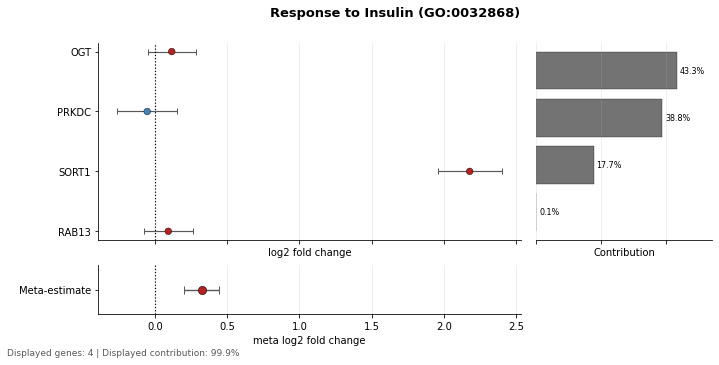

In [52]:
from plotting import ForestPlotter

term = "Response to Insulin (GO:0032868)"
output = ForestPlotter(deseq_results, balanced_matrix, gene_ontology_results).plot_term(term, cutoff=0.9999)